# Context Classifier

## Self-Supervised Contrastive Learning

### Setup

In [ ]:
import os
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random

print("TF Version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TF Version: 2.10.1
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data Load & Initial Preprocessing

In [2]:
train_dirs = [
    'data_aug_varsize/cropped_images/train/sol',
    'data_aug_varsize/cropped_images/train/mtga',
    'data_aug_varsize/cropped_images/train/mtgl',
    'data_aug_varsize/cropped_images/train/hs'
]

val_dirs = [
    'data_aug_varsize/cropped_images/val/sol',
    'data_aug_varsize/cropped_images/val/mtga',
    'data_aug_varsize/cropped_images/val/mtgl',
    'data_aug_varsize/cropped_images/val/hs'
]

IMG_SIZE = 128

def load_images_from_dirs(dirs, label_start_idx=0):
    images = []
    labels = []
    for label_idx, data_dir in enumerate(dirs, start=label_start_idx):
        image_files = list(Path(data_dir).glob('*.png')) + \
                      list(Path(data_dir).glob('*.jpeg')) + \
                      list(Path(data_dir).glob('*.jpg'))
        
        print(f"\nLoading from {data_dir} ({len(image_files)} images)...")

        for i, img_path in enumerate(image_files):
            if i % 100 == 0:
                print(f"  Processed {i}/{len(image_files)}")
            
            img = tf.io.read_file(str(img_path))
            img = tf.image.decode_image(img, channels=3)

            # Resize and pad
            shape = tf.shape(img)
            h = tf.cast(shape[0], tf.float32)
            w = tf.cast(shape[1], tf.float32)
            scale = IMG_SIZE / tf.maximum(h, w)
            new_h = tf.cast(h * scale, tf.int32)
            new_w = tf.cast(w * scale, tf.int32)
            img = tf.image.resize(img, [new_h, new_w])
            img = tf.image.resize_with_crop_or_pad(
                img, 
                IMG_SIZE, 
                IMG_SIZE
            )

            images.append(img)
            labels.append(label_idx)
    return tf.stack(images), tf.convert_to_tensor(labels)

# Load train/val images
train_images, train_labels = load_images_from_dirs(train_dirs)
val_images, val_labels = load_images_from_dirs(val_dirs)

# Create TF datasets
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_images, train_labels)
)
val_ds = tf.data.Dataset.from_tensor_slices(
    (val_images, val_labels)
)


# Label mapping
label_mapping = {
    0: 'sol',
    1: 'mtga',
    2: 'mtgl',
    3: 'hs'
}

print("\nLabel mapping:")
for num, name in label_mapping.items():
    print(f"Class {num}: {name}")

print("Done")


Loading from data_aug_varsize/cropped_images/train/sol (2100 images)...
  Processed 0/2100
  Processed 100/2100
  Processed 200/2100
  Processed 300/2100
  Processed 400/2100
  Processed 500/2100
  Processed 600/2100
  Processed 700/2100
  Processed 800/2100
  Processed 900/2100
  Processed 1000/2100
  Processed 1100/2100
  Processed 1200/2100
  Processed 1300/2100
  Processed 1400/2100
  Processed 1500/2100
  Processed 1600/2100
  Processed 1700/2100
  Processed 1800/2100
  Processed 1900/2100
  Processed 2000/2100

Loading from data_aug_varsize/cropped_images/train/mtga (2712 images)...
  Processed 0/2712
  Processed 100/2712
  Processed 200/2712
  Processed 300/2712
  Processed 400/2712
  Processed 500/2712
  Processed 600/2712
  Processed 700/2712
  Processed 800/2712
  Processed 900/2712
  Processed 1000/2712
  Processed 1100/2712
  Processed 1200/2712
  Processed 1300/2712
  Processed 1400/2712
  Processed 1500/2712
  Processed 1600/2712
  Processed 1700/2712
  Processed 1800/27

### Display Sample Images

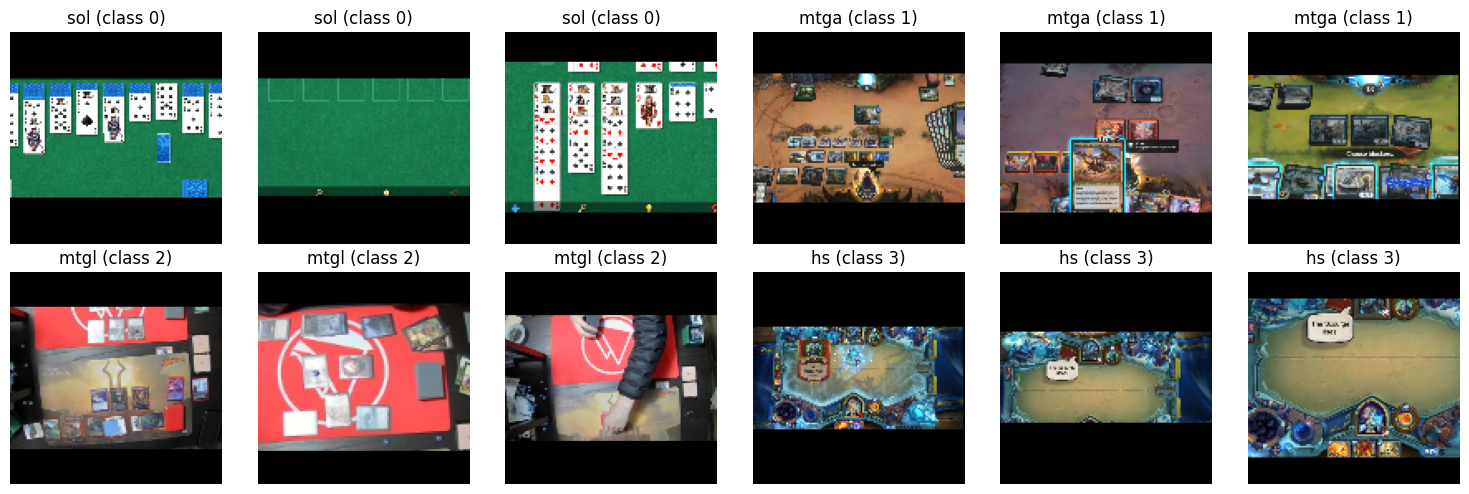

In [41]:
train_images_np = train_images.numpy()
train_labels_np = train_labels.numpy()

# Plot random images from each class
plt.figure(figsize=(15, 5))
unique_labels = np.unique(train_labels_np)

for i, label in enumerate(unique_labels):
    indices = np.where(train_labels_np == label)[0]
    sample_indices = np.random.choice(
        indices, 
        size=3, 
        replace=False
    )

    for j, idx in enumerate(sample_indices):
        plt.subplot(2, 6, i * 3 + j + 1)
        plt.imshow(train_images_np[idx].astype('uint8'))
        class_name = label_mapping[int(label)]
        plt.title(f'{class_name} (class {label})')
        plt.axis('off')

plt.tight_layout()
plt.show()


### Verify Training & Validation Distributions

In [24]:
# Training images per class
unique_train_labels, train_counts = np.unique(
    train_labels, 
    return_counts=True
)
print("\nTraining Class Distribution:")
for label, count in zip(unique_train_labels, train_counts):
    class_name = label_mapping[int(label)]
    print(f"{class_name} ({label}): {count} images")

# Validation images per class
unique_val_labels, val_counts = np.unique(
    val_labels, 
    return_counts=True
)
print("\nValidation Class Distribution:")
for label, count in zip(unique_val_labels, val_counts):
    class_name = label_mapping[int(label)]
    print(f"{class_name} ({label}): {count} images")



Training Class Distribution:
sol (0): 2100 images
mtga (1): 2712 images
mtgl (2): 1638 images
hs (3): 150 images

Validation Class Distribution:
sol (0): 522 images
mtga (1): 672 images
mtgl (2): 408 images
hs (3): 36 images


### SimCLR Functions & Encoder

In [3]:
# Data Augmentation
def simclr_augment(image):
    image = tf.image.resize_with_crop_or_pad(image, IMG_SIZE + 4, IMG_SIZE + 4)
    image = tf.image.random_crop(image, size=[IMG_SIZE, IMG_SIZE, 3])
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.5)
    image = tf.image.random_contrast(image, 0.5, 1.5)
    image = tf.image.adjust_saturation(image, np.random.uniform(0.5, 1.5))
    image = tf.image.adjust_hue(image, np.random.uniform(-0.2, 0.2))
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def simclr_preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return (simclr_augment(image), simclr_augment(image)), label

In [4]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_contrastive_ds = (train_ds
    .map(simclr_preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

# Encoder Model
def get_encoder():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = tf.keras.layers.Conv2D(128, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128)(x)
    return tf.keras.Model(inputs, x, name='encoder')

# Projection Head
def add_projection_head(encoder):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    features = encoder(inputs)
    x = tf.keras.layers.Dense(128, activation='relu')(features)
    outputs = tf.keras.layers.Dense(64)(x)
    return tf.keras.Model(inputs, outputs, name='simclr_model')

def contrastive_loss(embeddings, temperature=0.5):
    embeddings = tf.math.l2_normalize(embeddings, axis=1)
    similarities = tf.matmul(embeddings, embeddings, transpose_b=True)
    batch_size = tf.shape(embeddings)[0] // 2
    labels = tf.range(batch_size)
    labels = tf.concat([labels, labels], axis=0)
    logits_mask = tf.linalg.set_diag(
        tf.ones_like(similarities), 
        tf.zeros_like(tf.linalg.diag_part(similarities))
    )
    logits = similarities / temperature
    logits = logits * logits_mask
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        labels, 
        logits, 
        from_logits=True
    )
    return tf.reduce_mean(loss)


### Encoder Training

In [5]:
encoder = get_encoder()
simclr_model = add_projection_head(encoder)
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x1, x2):
    with tf.GradientTape() as tape:
        z1 = simclr_model(x1, training=True)
        z2 = simclr_model(x2, training=True)
        embeddings = tf.concat([z1, z2], axis=0)
        loss = contrastive_loss(embeddings)
    gradients = tape.gradient(loss, simclr_model.trainable_variables)
    optimizer.apply_gradients(
        zip(gradients, simclr_model.trainable_variables)
    )
    return loss

# Training Loop
simclr_loss_history = []

EPOCHS = 20

for epoch in range(EPOCHS):
    epoch_loss = []
    print(f"Epoch {epoch+1}/{EPOCHS}")
    for step, ((x1, x2), _) in enumerate(train_contrastive_ds):
        loss = train_step(x1, x2)
        epoch_loss.append(loss.numpy())
        if step % 10 == 0:
            print(f"Step {step}: Contrastive Loss = {loss.numpy():.4f}")
    simclr_loss_history.append(np.mean(epoch_loss))

Epoch 1/20
Step 0: Contrastive Loss = 4.6175
Step 10: Contrastive Loss = 4.0158
Step 20: Contrastive Loss = 4.1789
Step 30: Contrastive Loss = 3.9229
Step 40: Contrastive Loss = 4.0201
Step 50: Contrastive Loss = 3.9999
Step 60: Contrastive Loss = 3.8617
Step 70: Contrastive Loss = 3.9803
Step 80: Contrastive Loss = 3.9313
Step 90: Contrastive Loss = 3.8920
Step 100: Contrastive Loss = 3.8819
Step 110: Contrastive Loss = 3.9288
Step 120: Contrastive Loss = 3.9935
Step 130: Contrastive Loss = 3.8692
Step 140: Contrastive Loss = 3.9747
Step 150: Contrastive Loss = 3.8925
Step 160: Contrastive Loss = 3.7907
Step 170: Contrastive Loss = 3.8879
Step 180: Contrastive Loss = 3.9473
Step 190: Contrastive Loss = 3.8428
Step 200: Contrastive Loss = 3.7933
Epoch 2/20
Step 0: Contrastive Loss = 3.8481
Step 10: Contrastive Loss = 3.8487
Step 20: Contrastive Loss = 3.9401
Step 30: Contrastive Loss = 3.8289
Step 40: Contrastive Loss = 3.8569
Step 50: Contrastive Loss = 3.7539
Step 60: Contrastive Los

### Embedding Visualization

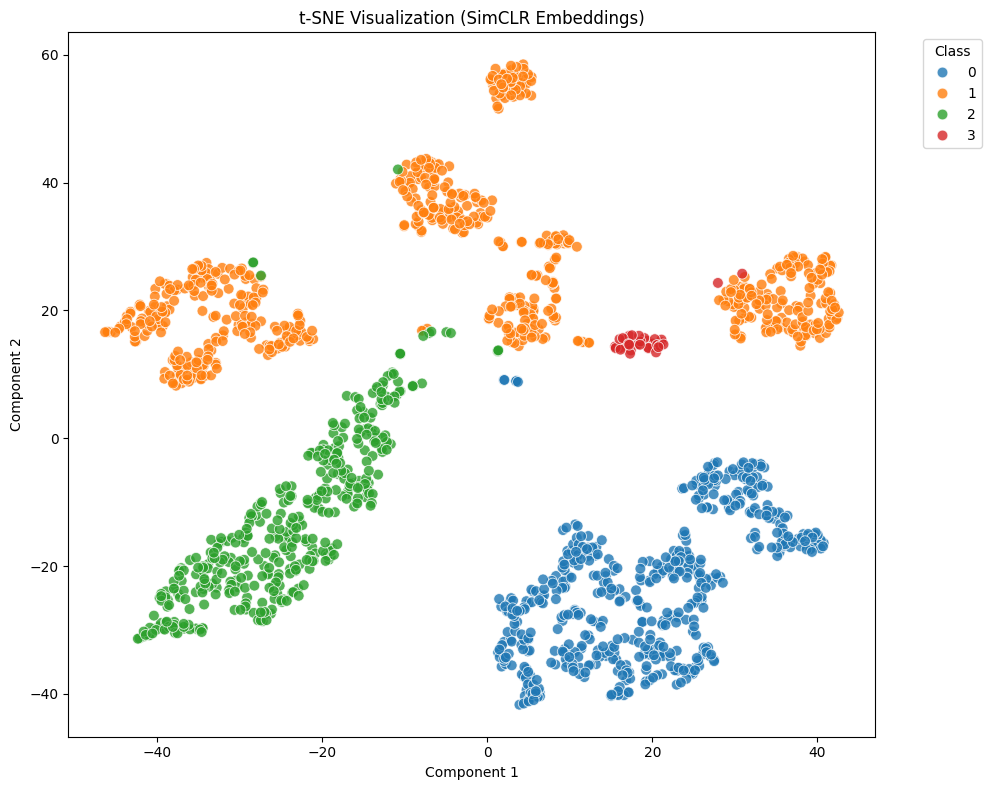

In [19]:
# Visualize Embeddings with t-SNE
val_subset = val_ds.map(preprocess).batch(BATCH_SIZE)
all_embeddings = []
all_labels = []

for images, labels in val_subset:
    batch_embeddings = encoder(images, training=False).numpy()
    all_embeddings.append(batch_embeddings)
    all_labels.append(labels.numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.concatenate(all_labels, axis=0)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embeddings_2d[:, 0], 
    y=embeddings_2d[:, 1], 
    hue=labels, 
    palette='tab10', 
    s=60, 
    alpha=0.8
)
plt.title("t-SNE Visualization (SimCLR Embeddings)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Training Classification Layer

In [21]:
encoder.trainable = False

train_classifier_ds = (
    train_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE))

val_classifier_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE))

classifier = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

classifier.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

history = classifier.fit(
    train_classifier_ds,
    validation_data=val_classifier_ds,
    epochs=5
)

val_loss, val_acc = classifier.evaluate(val_classifier_ds)
print("Validation Loss: ", val_loss, " Validation Accuracy: ", val_acc)

Epoch 1/5
207/207 [==============================] - 3s 9ms/step - loss: 0.1486 - accuracy: 0.9512 - val_loss: 0.0286 - val_accuracy: 0.9933
Epoch 2/5
207/207 [==============================] - 2s 8ms/step - loss: 0.0243 - accuracy: 0.9944 - val_loss: 0.0186 - val_accuracy: 0.9976
Epoch 3/5
207/207 [==============================] - 2s 8ms/step - loss: 0.0162 - accuracy: 0.9965 - val_loss: 0.0138 - val_accuracy: 0.9969
Epoch 4/5
207/207 [==============================] - 2s 8ms/step - loss: 0.0126 - accuracy: 0.9971 - val_loss: 0.0144 - val_accuracy: 0.9976
Epoch 5/5
52/52 [==============================] - 0s 6ms/step - loss: 0.0095 - accuracy: 0.9982
Validation Loss:  0.00954525638371706  Validation Accuracy:  0.9981684684753418


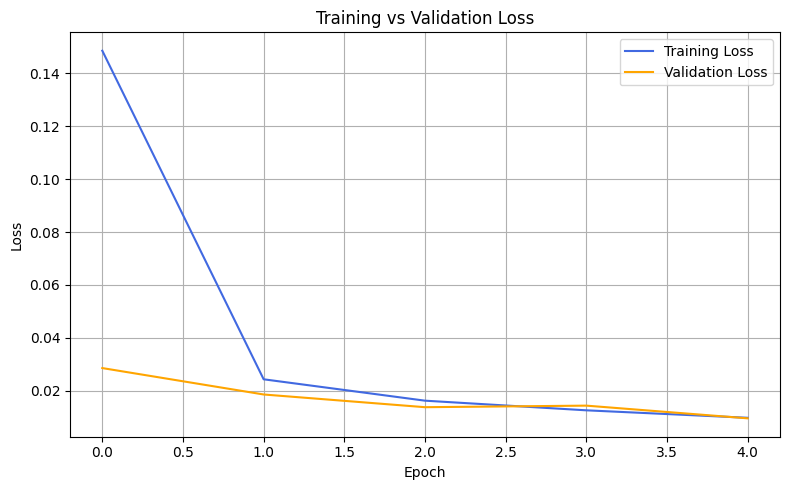

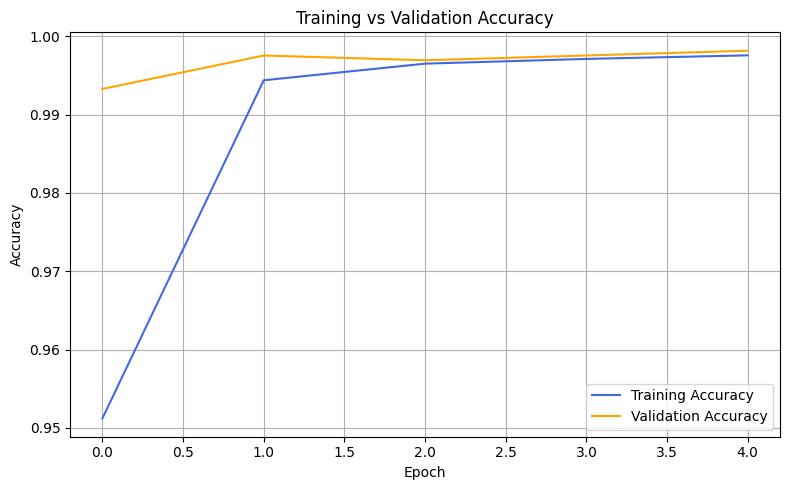

In [48]:
# Plot training vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', color='royalblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot training vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='royalblue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

52/52 [==============================] - 0s 5ms/step
Validation Accuracy: 0.9969


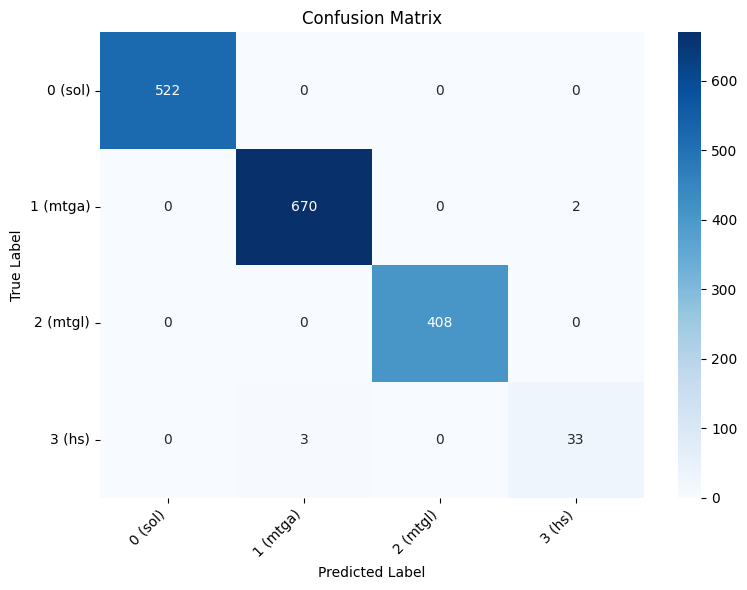

In [8]:
# Predict and confusion matrix
val_predictions = classifier.predict(val_classifier_ds)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.concatenate([labels for _, labels in val_classifier_ds])

# Calculate accuracy
accuracy = np.mean(val_pred_classes == val_true_classes)
print(f"Validation Accuracy: {accuracy:.4f}")

cm = confusion_matrix(val_true_classes, val_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add class labels to axes
tick_labels = [f'{i} ({label_mapping[i]})' for i in range(4)]
plt.xticks(np.arange(4) + 0.5, tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(4) + 0.5, tick_labels, rotation=0)

plt.tight_layout()
plt.show()

## Supervised Contrastive Learning

### SupCon Function

In [9]:
def supcon_preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return ((simclr_augment(image), simclr_augment(image)), label)

supcon_ds = (
    train_ds
    .map(supcon_preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

def supervised_contrastive_loss(features, labels, temperature=0.07):
    features = tf.math.l2_normalize(features, axis=1)
    
    labels = tf.cast(labels, tf.int32)
    mask = tf.equal(tf.expand_dims(labels, 1), tf.expand_dims(labels, 0))
    
    logits = tf.divide(tf.matmul(features, tf.transpose(features)), temperature)
    logits_mask = tf.cast(~tf.eye(tf.shape(labels)[0], dtype=tf.bool), tf.float32)
    
    exp_logits = tf.exp(logits) * logits_mask
    log_prob = logits - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-9)
    
    mask = tf.cast(mask, tf.float32) * logits_mask
    mean_log_prob_pos = tf.reduce_sum(mask * log_prob, axis=1) / (tf.reduce_sum(mask, axis=1) + 1e-9)
    
    loss = -tf.reduce_mean(mean_log_prob_pos)
    return loss

### Training

In [10]:
encoder_sup = get_encoder()
supcon_model = add_projection_head(encoder_sup)
optimizer_sup = tf.keras.optimizers.Adam()

@tf.function
def supcon_train_step(x1, x2, labels):
    with tf.GradientTape() as tape:
        z1 = supcon_model(x1, training=True)
        z2 = supcon_model(x2, training=True)
        features = tf.concat([z1, z2], axis=0)
        labels_concat = tf.concat([labels, labels], axis=0)
        loss = supervised_contrastive_loss(features, labels_concat)
    grads = tape.gradient(loss, supcon_model.trainable_variables)
    optimizer_sup.apply_gradients(zip(grads, supcon_model.trainable_variables))
    return loss

# Training loop
supcon_loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = []
    print(f"[SupCon] Epoch {epoch+1}/{EPOCHS}")
    for step, ((x1, x2), labels_batch) in enumerate(supcon_ds):
        loss = supcon_train_step(x1, x2, labels_batch)
        epoch_loss.append(loss.numpy())
        if step % 10 == 0:
            print(f"Step {step}: SupCon Loss = {loss.numpy():.4f}")
    supcon_loss_history.append(np.mean(epoch_loss))

[SupCon] Epoch 1/20
Step 0: SupCon Loss = 7.5540
Step 10: SupCon Loss = 3.9653
Step 20: SupCon Loss = 3.7048
Step 30: SupCon Loss = 3.8375
Step 40: SupCon Loss = 3.7044
Step 50: SupCon Loss = 3.8434
Step 60: SupCon Loss = 3.4907
Step 70: SupCon Loss = 3.6767
Step 80: SupCon Loss = 3.7078
Step 90: SupCon Loss = 3.5628
Step 100: SupCon Loss = 3.4783
Step 110: SupCon Loss = 3.6124
Step 120: SupCon Loss = 3.7026
Step 130: SupCon Loss = 3.5442
Step 140: SupCon Loss = 3.9224
Step 150: SupCon Loss = 3.7650
Step 160: SupCon Loss = 3.7138
Step 170: SupCon Loss = 3.5328
Step 180: SupCon Loss = 3.6352
Step 190: SupCon Loss = 3.3247
Step 200: SupCon Loss = 3.3512
[SupCon] Epoch 2/20
Step 0: SupCon Loss = 3.4718
Step 10: SupCon Loss = 3.5603
Step 20: SupCon Loss = 3.7449
Step 30: SupCon Loss = 3.4724
Step 40: SupCon Loss = 3.3977
Step 50: SupCon Loss = 3.5437
Step 60: SupCon Loss = 3.3152
Step 70: SupCon Loss = 3.4583
Step 80: SupCon Loss = 3.2531
Step 90: SupCon Loss = 3.4645
Step 100: SupCon Loss

### Embedding Visualization

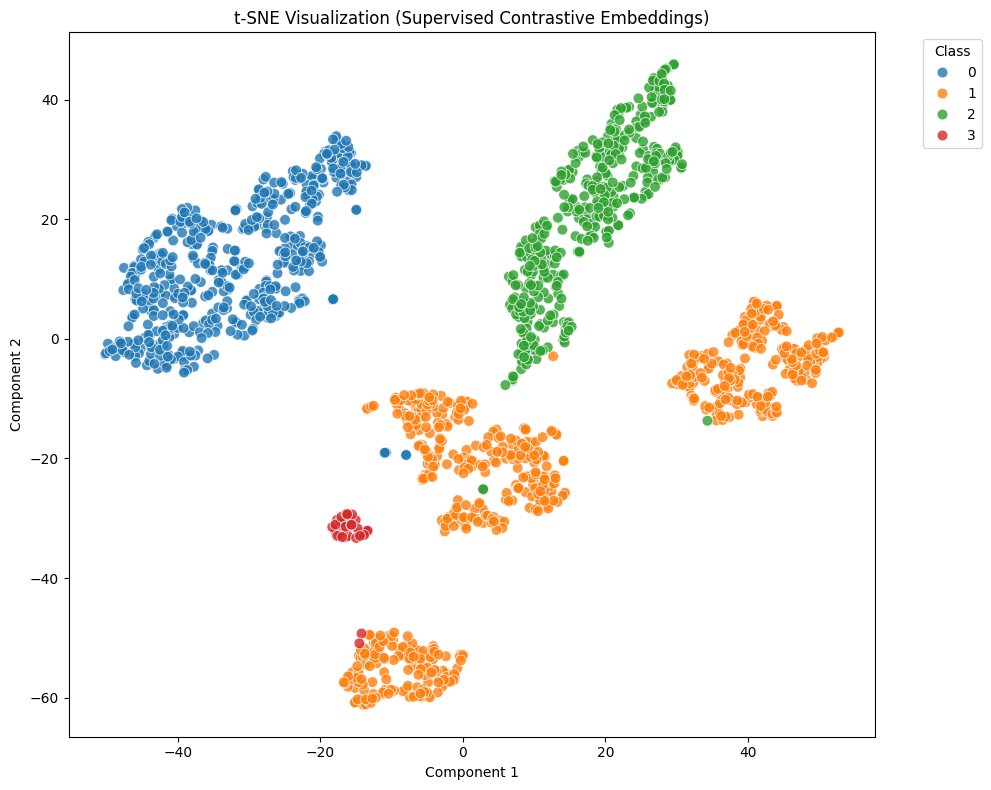

In [11]:
val_subset_sup = val_ds.map(preprocess).batch(BATCH_SIZE)
all_embeddings_sup = []
all_labels_sup = []

for images, labels in val_subset_sup:
    batch_embeddings = encoder_sup(images, training=False).numpy()
    all_embeddings_sup.append(batch_embeddings)
    all_labels_sup.append(labels.numpy())

embeddings_sup = np.concatenate(all_embeddings_sup, axis=0)
labels_sup = np.concatenate(all_labels_sup, axis=0)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d_sup = tsne.fit_transform(embeddings_sup)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embeddings_2d_sup[:, 0], 
    y=embeddings_2d_sup[:, 1], 
    hue=labels_sup, 
    palette='tab10', 
    s=60, 
    alpha=0.8
)
plt.title("t-SNE Visualization (Supervised Contrastive Embeddings)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Training Classification Layer

In [12]:
encoder_sup.trainable = False

classifier_sup = tf.keras.Sequential([
    encoder_sup,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

classifier_sup.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

classifier_sup.fit(train_classifier_ds, validation_data=val_classifier_ds, epochs=5)

val_loss_sup, val_acc_sup = classifier_sup.evaluate(val_classifier_ds)
print("SupCon Validation Loss: ", val_loss_sup, " Validation Accuracy: ", val_acc_sup)

Epoch 1/5
207/207 [==============================] - 3s 10ms/step - loss: 0.1312 - accuracy: 0.9636 - val_loss: 0.0318 - val_accuracy: 0.9915
Epoch 2/5
207/207 [==============================] - 2s 9ms/step - loss: 0.0244 - accuracy: 0.9956 - val_loss: 0.0167 - val_accuracy: 0.9976
Epoch 3/5
207/207 [==============================] - 2s 8ms/step - loss: 0.0161 - accuracy: 0.9968 - val_loss: 0.0135 - val_accuracy: 0.9969
Epoch 4/5
207/207 [==============================] - 2s 8ms/step - loss: 0.0125 - accuracy: 0.9971 - val_loss: 0.0110 - val_accuracy: 0.9982
Epoch 5/5
52/52 [==============================] - 0s 5ms/step - loss: 0.0088 - accuracy: 0.9982
SupCon Validation Loss:  0.00879543274641037  Validation Accuracy:  0.9981684684753418


### Model Evaluation

52/52 [==============================] - 0s 5ms/step
Validation Accuracy: 0.9982


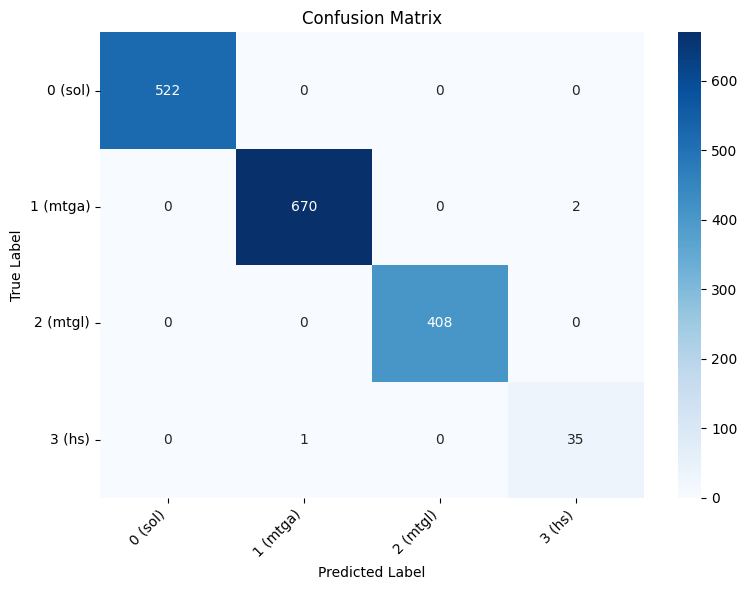

In [13]:
# Generate predictions and confusion matrix
val_predictions = classifier_sup.predict(val_classifier_ds)
val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.concatenate([labels for _, labels in val_classifier_ds])

# Calculate accuracy
accuracy = np.mean(val_pred_classes == val_true_classes)
print(f"Validation Accuracy: {accuracy:.4f}")

cm = confusion_matrix(val_true_classes, val_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add class labels to axes
tick_labels = [f'{i} ({label_mapping[i]})' for i in range(4)]
plt.xticks(np.arange(4) + 0.5, tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(4) + 0.5, tick_labels, rotation=0)

plt.tight_layout()
plt.show()

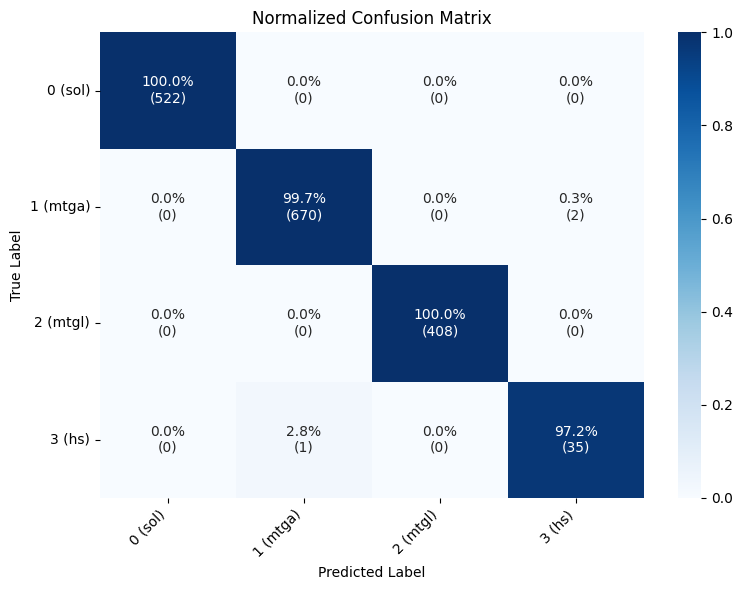

In [30]:
cm_raw = confusion_matrix(val_true_classes, val_pred_classes)

# Normalize by for percentages
cm_percent = cm_raw.astype('float') / cm_raw.sum(axis=1, keepdims=True)

# Annotations with both percentage and count
annot = np.empty_like(cm_percent).astype(str)
for i in range(cm_raw.shape[0]):
    for j in range(cm_raw.shape[1]):
        pct = cm_percent[i, j] * 100
        annot[i, j] = f"{pct:.1f}%\n({cm_raw[i, j]})"

plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=annot, fmt='', cmap='Blues', cbar=True, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

tick_labels = [f'{i} ({label_mapping[i]})' for i in range(4)]
plt.xticks(np.arange(4) + 0.5, tick_labels, rotation=45, ha='right')
plt.yticks(np.arange(4) + 0.5, tick_labels, rotation=0)

plt.tight_layout()
plt.show()

In [14]:
classifier_sup.save("models/context_classifier.h5")

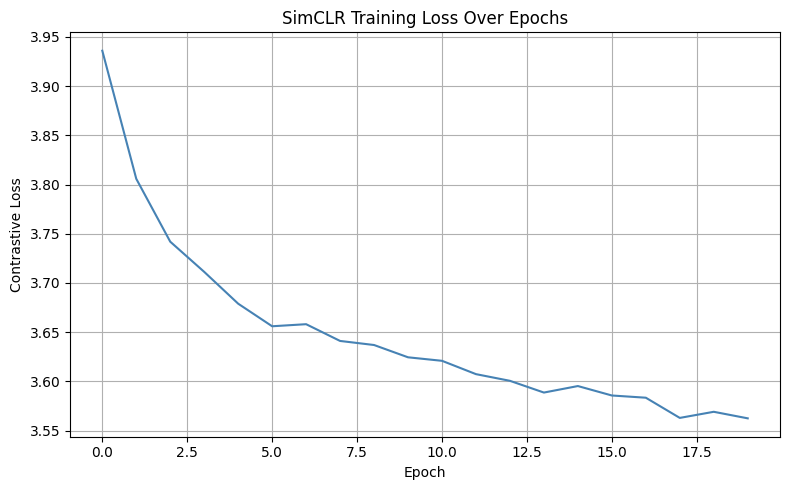

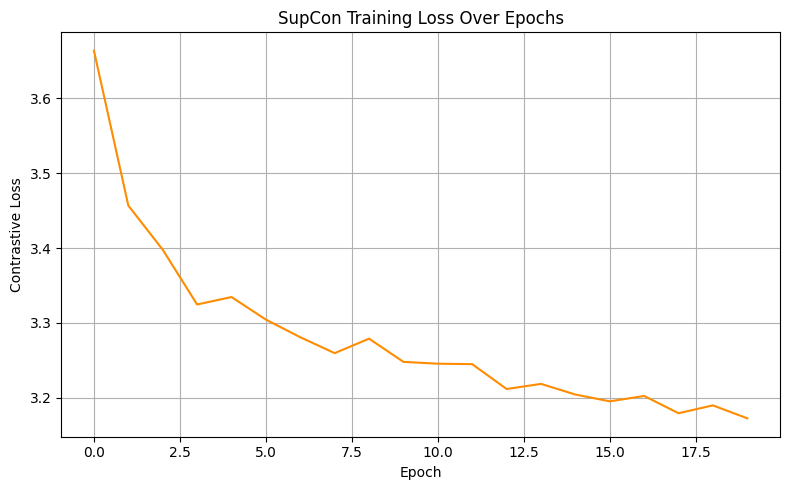

In [17]:
# Plot SimCLR Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(simclr_loss_history, color='steelblue')
plt.title("SimCLR Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot SupCon Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(supcon_loss_history, color='darkorange')
plt.title("SupCon Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.grid(True)
plt.tight_layout()
plt.show()
